
# 🔍 Notebook 2 — Exploratory Data Analysis (EDA)

**Mục tiêu notebook:**
- Phân tích phân phối target và class imbalance
- Khám phá missing values, phân phối numeric features
- Tìm correlation giữa features và target
- Phát hiện outliers
- Phân tích categorical features (chi-square test)
- Kết luận EDA: top features, missing strategy

---

## 🗺️ Lộ trình 15 bước — Pipeline ML đầy đủ

| # | Bước | Notebook | Trạng thái |
|:-:|------|----------|:----------:|
| 1 | Đặt vấn đề | NB1 | ✅ Hoàn thành |
| 2 | Thu thập dữ liệu | NB1 | ✅ Hoàn thành |
| **3** | **Tiền xử lý & EDA** | **📌 NB2** | **▶ Đang học** |
| **4** | **Định nghĩa Target** | **📌 NB2** | **▶ Đang học** |
| 5 | Feature Engineering | NB3 | ⬜ |
| 6 | Feature Selection | NB3 | ⬜ |
| 7 | Train/Test Split + Scale | NB3 | ⬜ |
| 8 | Chọn mô hình | NB3 | ⬜ |
| 9 | Huấn luyện | NB3 | ⬜ |
| 10 | Đánh giá baseline | NB3 | ⬜ |
| 11 | Feature Reduction | NB3 | ⬜ |
| 12 | So sánh & Phân tích sâu | NB4 | ⬜ |
| 13 | Kết luận Model tốt nhất | NB4 | ⬜ |
| 14 | KPI Check | NB4 | ⬜ |
| 15 | Threshold Optimization | NB4 | ⬜ |

> 💡 **Notebook này bao phủ: Bước 3 & 4 / 15** — Khám phá dữ liệu để hiểu cần làm sạch gì trước khi vào NB3


In [58]:
# ============================================================
# SECTION 0: Import thư viện
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Style ---
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'axes.grid'        : True,
    'grid.alpha'       : 0.2,
    'grid.linestyle'   : '--',
})

# ── PAL: Bộ màu thống nhất toàn notebook (Business Report Standard) ──────────
# Nguyên tắc: mỗi màu mang một Ý nghĩa cố định — không thay đổi giữa các biểu đồ
PAL = {
    'primary' : '#2563EB',   # Xanh dương đậm  — thanh đơn, metric chính
    'pos'     : '#059669',   # Xanh lá đậm     — tái mua (label=1), tín hiệu tốt
    'neg'     : '#DC2626',   # Đỏ đậm          — không tái mua (label=0), rủi ro
    'accent'  : '#7C3AED',   # Tím             — highlight, biến phụ
    'warning' : '#F59E0B',   # Vàng amber      — ngưỡng, cảnh báo
    'neutral' : '#94A3B8',   # Xám             — baseline, trung tính
    'light_pos': '#D1FAE5',  # Xanh nhạt       — background tín hiệu tốt
    'light_neg': '#FEE2E2',  # Đỏ nhạt         — background rủi ro
}

# Ánh xạ nhãn repurchase → màu theo Visual Identity (hồng / xanh pastel)
PALETTE = {0: '#F7CAD0', 1: '#A0C4FF'}   # Class 0: hồng #F7CAD0 | Class 1: xanh #A0C4FF
PALETTE_EDGE = {0: '#C97680', 1: '#4A80C4'}  # Viền tương ứng

# --- Đường dẫn ---
BASE_DIR  = Path('.').resolve()
DATA_DIR  = BASE_DIR / 'data'

pd.set_option('display.float_format', '{:,.4f}'.format)
print('✅ Libraries loaded | PAL unified palette ready')
print(f'   PALETTE[0]=#F7CAD0 (hồng) | PALETTE[1]=#A0C4FF (xanh) — VI class colors')
print('   → Mỗi màu mang một ý nghĩa cố định trong toàn bộ notebook')


✅ Libraries loaded | PAL unified palette ready
   PALETTE[0]=#F7CAD0 (hồng) | PALETTE[1]=#A0C4FF (xanh) — VI class colors
   → Mỗi màu mang một ý nghĩa cố định trong toàn bộ notebook


In [59]:
# Load dữ liệu từ Notebook 1
df = pd.read_csv(DATA_DIR / 'synthetic_data.csv', encoding='utf-8-sig')
print(f'✅ Loaded: {df.shape[0]:,} dòng × {df.shape[1]} cột')
df.head(3)

✅ Loaded: 61,728 dòng × 20 cột


,user_id,product_category,age,dominant_gender,dominant_location,total_view,total_click,total_cart,total_wishlist,total_interactions,click_through_rate,cart_rate,unique_brands,avg_price,avg_discount,avg_purchase_value,avg_rating,user_total_categories,category_share,repurchase
0,U0001,Outdoor,44,Nam,Đà Nẵng,34,18,12,4,78,0.5294,0.6667,9,657000,9.7900,592000,4.2000,5,0.3000,1
1,U0001,Gia dụng,44,Nam,Đà Nẵng,8,5,2,3,21,0.6250,0.4000,3,7655000,16.0800,6424000,4.3000,5,0.0808,0
2,U0001,Điện tử,44,Nam,Đà Nẵng,12,9,3,12,47,0.7500,0.3333,9,9565000,10.1500,8594000,4.9000,5,0.1808,1



---
## 📌 Bước 4 / 15 — Định nghĩa Target

**Target:** `repurchase` (binary)
- `0` = Không tái mua (purchase_count < 5) — **Majority class: ~67.2%**
- `1` = Tái mua (purchase_count ≥ 5) — **Minority class: ~32.8%**
- Nguồn gốc: Otsu thresholding T* = 4.02 → ngưỡng tự động, không bias

### 1. Phân phối Target


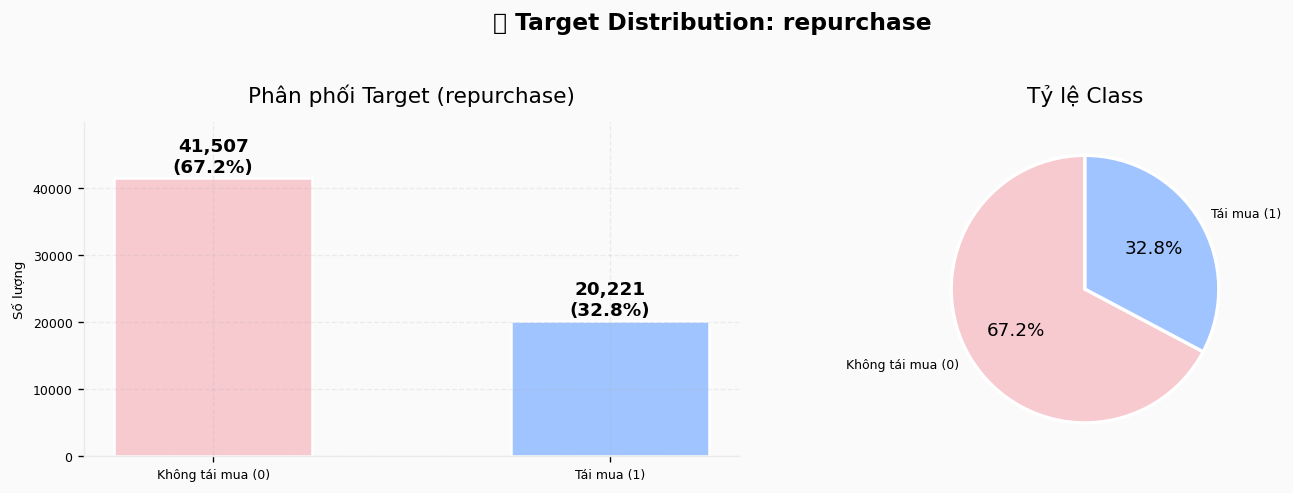


📋 Class Distribution:
  Không tái mua (0): 41,507 (67.24%)
  Tái mua (1): 20,221 (32.76%)

  Imbalance ratio (minority/majority): 0.487


In [60]:
# ============================================================
# SECTION 1: Target distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Count plot ---
counts = df['repurchase'].value_counts().sort_index()
colors = [PALETTE[0], PALETTE[1]]
bars = axes[0].bar(['Không tái mua (0)', 'Tái mua (1)'],
                   counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Phân phối Target (repurchase)', fontsize=13, pad=12)
axes[0].set_ylabel('Số lượng')
axes[0].set_ylim(0, max(counts.values) * 1.2)

# --- Pie chart ---
axes[1].pie(counts.values, labels=['Không tái mua (0)', 'Tái mua (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Tỷ lệ Class', fontsize=13, pad=12)

plt.suptitle('📊 Target Distribution: repurchase', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# In kết quả
print('\n📋 Class Distribution:')
for val, count in counts.items():
    label = 'Tái mua' if val == 1 else 'Không tái mua'
    print(f'  {label} ({val}): {count:,} ({count/len(df)*100:.2f}%)')
print(f'\n  Imbalance ratio (minority/majority): {min(counts)/max(counts):.3f}')


---
## 📌 Bước 3 / 15 — Tiền xử lý & Khám phá dữ liệu (EDA)

> **Ghi chú pipeline:** Bước 3 trong NB2 là giai đoạn **PHÂN TÍCH** — phát hiện vấn đề cần xử lý. Giai đoạn **HÀNH ĐỘNG** (impute, encode, clean thực tế) diễn ra ở NB3 trước khi train model.

### 2. Phân tích Missing Values & Outliers


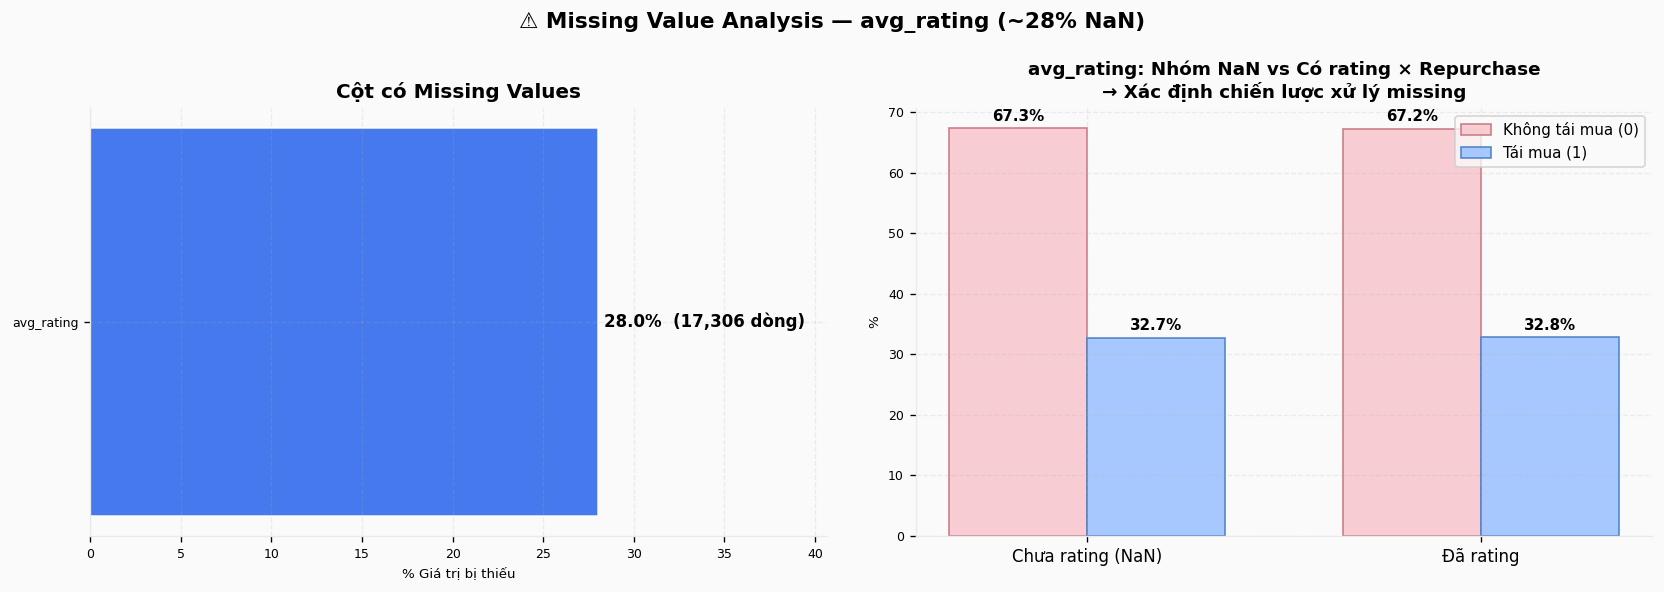


📋 Missing Value Summary:
  avg_rating NaN: 17,306 (28.04%)
  → Strategy NB3: Impute NaN = median (4.0) — không ảnh hưởng đến cơ chế gán nhãn
  → Nhãn repurchase được tạo từ purchase_count (Otsu T*=4.02), không phụ thuộc avg_rating


In [61]:
# ============================================================
# SECTION 2: Missing value analysis
# ============================================================
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = missing / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel trái: Tỷ lệ missing (PAL['primary'] — metric đơn, không mang nghĩa tốt/xấu) ---
bars = axes[0].barh(missing.index, missing_pct.values,
                    color=PAL['primary'], edgecolor='white', height=0.5, alpha=0.85)
for bar, (col, pct) in zip(bars, zip(missing.index, missing_pct.values)):
    axes[0].text(pct + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct:.1f}%  ({missing[col]:,} dòng)',
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('% Giá trị bị thiếu')
axes[0].set_title('Cột có Missing Values', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, missing_pct.max() * 1.45)
axes[0].set_facecolor('#FAFAFA')

# --- Panel phải: avg_rating NaN vs non-NaN × repurchase ---
# Câu hỏi business: "Người chưa rating có xu hướng tái mua khác không?"
df_temp = df.copy()
df_temp['has_rating'] = (~df['avg_rating'].isna()).astype(int)
cross = pd.crosstab(df_temp['has_rating'], df_temp['repurchase'], normalize='index') * 100
cross.index = ['Chưa rating (NaN)', 'Đã rating']
cross.columns = ['Không tái mua (0)', 'Tái mua (1)']

ax2 = axes[1]
x = np.arange(len(cross))
w = 0.35
b1 = ax2.bar(x - w/2, cross['Không tái mua (0)'], width=w,
             color=PALETTE[0], edgecolor=PALETTE_EDGE[0], label='Không tái mua (0)', alpha=0.92)
b2 = ax2.bar(x + w/2, cross['Tái mua (1)'],       width=w,
             color=PALETTE[1], edgecolor=PALETTE_EDGE[1], label='Tái mua (1)', alpha=0.92)
ax2.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
ax2.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(cross.index, fontsize=10)
ax2.set_ylabel('%')
ax2.set_title('avg_rating: Nhóm NaN vs Có rating × Repurchase\n'
              '→ Xác định chiến lược xử lý missing',
              fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.set_facecolor('#FAFAFA')

plt.suptitle('⚠️ Missing Value Analysis — avg_rating (~28% NaN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 Missing Value Summary:')
print(f'  avg_rating NaN: {missing.get("avg_rating", 0):,} ({missing_pct.get("avg_rating", 0):.2f}%)')
print('  → Strategy NB3: Impute NaN = median (4.0) — không ảnh hưởng đến cơ chế gán nhãn')
print('  → Nhãn repurchase được tạo từ purchase_count (Otsu T*=4.02), không phụ thuộc avg_rating')


## 3. Phân phối Numeric Features

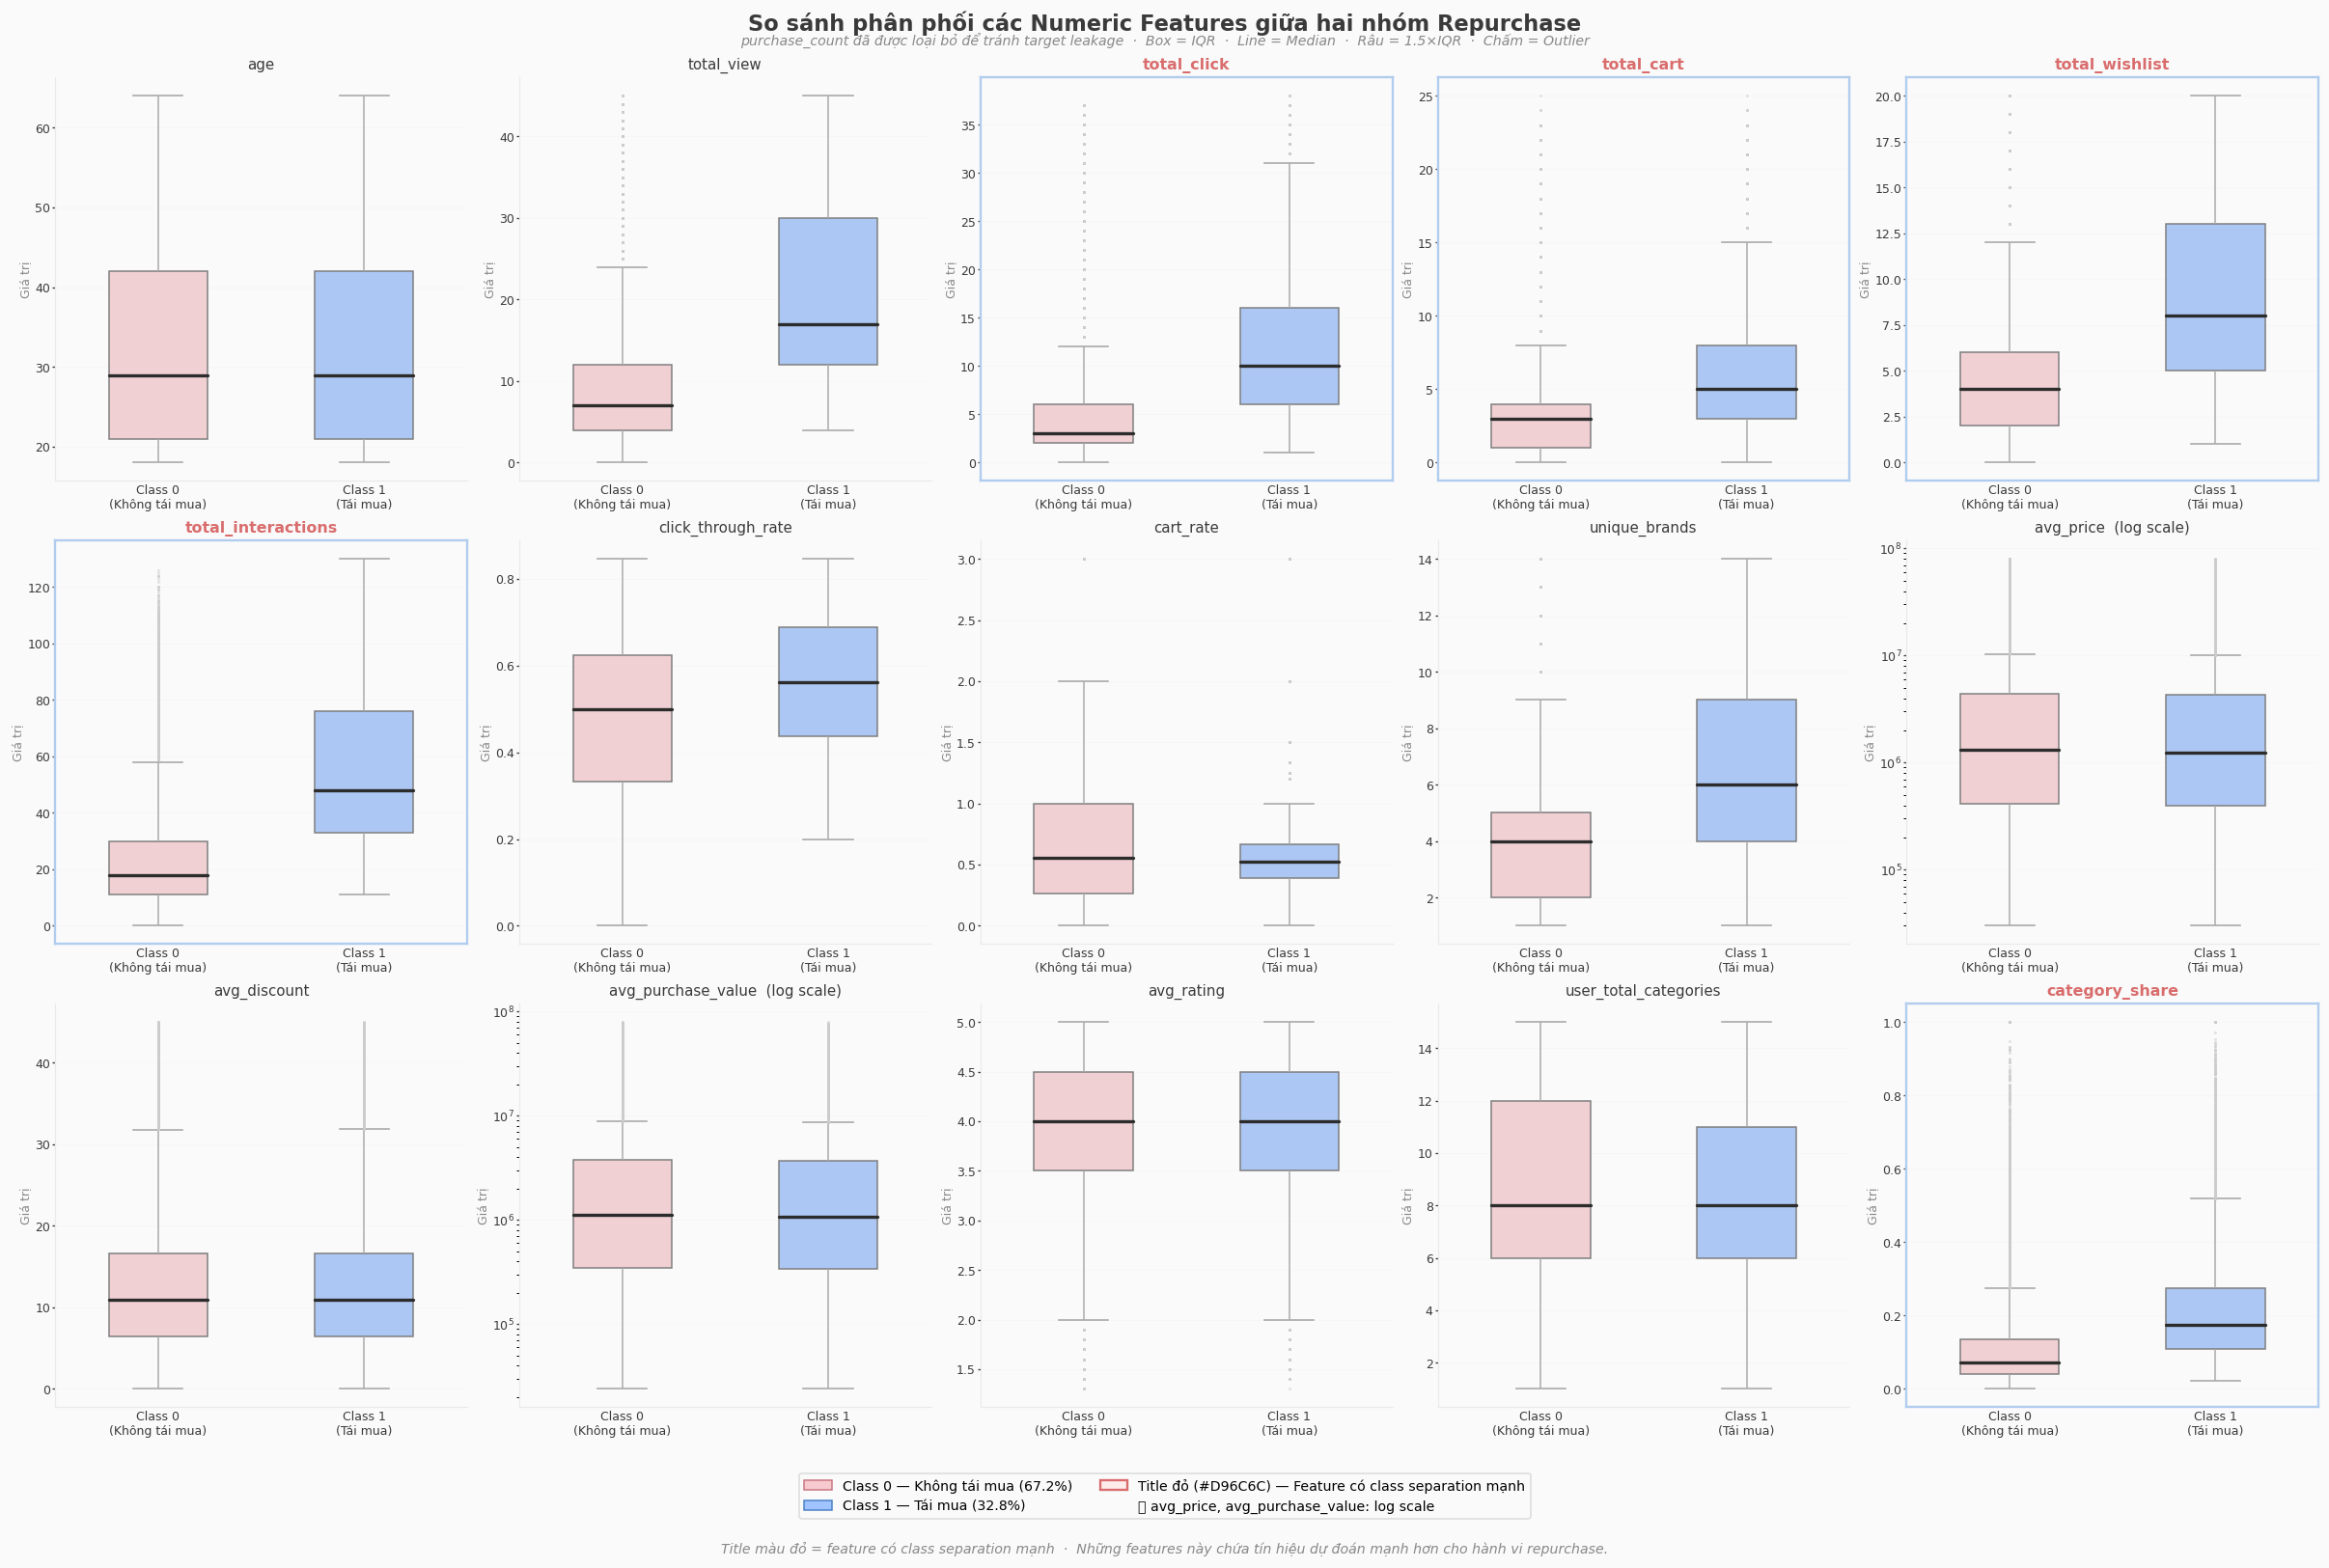

✅ Boxplot Grid (publication-quality) hoàn thành:
   Layout     : 3 hàng × 5 cột  |  15 features
   Class 0    : #F7CAD0 (pastel pink)   — Không tái mua (67.2%)
   Class 1    : #A0C4FF (pastel blue)   — Tái mua (32.8%)
   🔴 Highlight (red title #D96C6C) : ['category_share', 'total_cart', 'total_click', 'total_interactions', 'total_wishlist']
   📐 Log scale : ['avg_price', 'avg_purchase_value']
   Saved      : data/boxplot_grid_repurchase.png  (150 dpi)


In [62]:
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── ① Visual Identity Constants ──────────────────────────────────────────────
VI = {
    'c0'      : '#F7CAD0',   # Pastel pink  — Class 0: Không tái mua
    'c1'      : '#A0C4FF',   # Pastel blue  — Class 1: Tái mua
    'c0_edge' : '#C97680',   # Edge/outline class 0
    'c1_edge' : '#4A80C4',   # Edge/outline class 1
    'median'  : '#2C2C2C',   # Median line — đậm, dễ đọc
    'whisker' : '#AAAAAA',   # Whisker + cap
    'flier'   : '#CCCCCC',   # Outlier dots — tối giản
    'bg'      : '#FAFAFA',   # Plot background
    'grid'    : '#EAEAEA',   # Gridlines — rất nhẹ
    'text'    : '#3A3A3A',   # Main text
    'sub'     : '#888888',   # Secondary text / annotation
    'hi_bdr'  : '#B0CCEE',   # Border màu nhạt cho highlighted subplots
    'hi_title': '#D96C6C',   # Title màu đỏ nhấn — features có class separation mạnh
}

# ── ② Feature Configuration ──────────────────────────────────────────────────
FEATURES = [
    'age', 'total_view', 'total_click', 'total_cart', 'total_wishlist',
    'total_interactions', 'click_through_rate', 'cart_rate',
    'unique_brands', 'avg_price', 'avg_discount', 'avg_purchase_value',
    'avg_rating', 'user_total_categories', 'category_share',
]

# Features có class separation mạnh → title đỏ đậm, border nhẹ (không dùng ⭐)
HIGHLIGHT_SET = {
    'total_click', 'total_cart', 'total_interactions',
    'category_share', 'total_wishlist',
}

# Features phân phối đuôi dài → log scale để tránh boxplot bị dẹt
LOG_SET = {'avg_price', 'avg_purchase_value'}

# Label hiển thị trên trục X
CLS_LABEL = {0: 'Class 0\n(Không tái mua)', 1: 'Class 1\n(Tái mua)'}

# ── ③ Matplotlib/Seaborn global style ────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 9,
    'axes.titlesize'   : 9.5,
    'axes.labelsize'   : 8,
    'xtick.labelsize'  : 7.5,
    'ytick.labelsize'  : 7.5,
    'axes.edgecolor'   : VI['grid'],
    'axes.linewidth'   : 0.8,
    'figure.facecolor' : VI['bg'],
    'axes.facecolor'   : VI['bg'],
})

# ── ④ Layout ─────────────────────────────────────────────────────────────────
N_ROWS, N_COLS = 3, 5

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(20, 12),
    facecolor=VI['bg'],
    constrained_layout=True,
)
axes_flat = axes.flatten()

# ── ⑤ Render Từng Subplot ────────────────────────────────────────────────────
for idx, feat in enumerate(FEATURES):
    ax     = axes_flat[idx]
    is_hi  = feat in HIGHLIGHT_SET
    is_log = feat in LOG_SET

    ax.set_facecolor(VI['bg'])

    # ── Chuẩn bị data ────────────────────────────────────────────────────────
    d0 = df[df['repurchase'] == 0][feat].dropna()
    d1 = df[df['repurchase'] == 1][feat].dropna()
    if is_log:
        d0 = d0[d0 > 0]
        d1 = d1[d1 > 0]

    df_sub = pd.concat([
        pd.DataFrame({'value': d0, 'Nhóm': CLS_LABEL[0]}),
        pd.DataFrame({'value': d1, 'Nhóm': CLS_LABEL[1]}),
    ], ignore_index=True)

    # ── Seaborn Boxplot ───────────────────────────────────────────────────────
    sns.boxplot(
        data    = df_sub,
        x       = 'Nhóm',
        y       = 'value',
        order   = [CLS_LABEL[0], CLS_LABEL[1]],
        palette = {CLS_LABEL[0]: VI['c0'], CLS_LABEL[1]: VI['c1']},
        width   = 0.48,
        linewidth   = 1.0,
        showfliers  = True,
        flierprops  = dict(marker='o', markersize=1.8,
                           markerfacecolor=VI['flier'],
                           markeredgecolor='none', alpha=0.55),
        medianprops = dict(color=VI['median'], linewidth=2.0,
                           solid_capstyle='round'),
        whiskerprops= dict(color=VI['whisker'], linewidth=0.9, linestyle='-'),
        capprops    = dict(color=VI['whisker'], linewidth=1.0),
        boxprops    = dict(linewidth=0.9),
        ax=ax,
    )

    # Log scale
    if is_log:
        ax.set_yscale('log')

    # ── Despine ───────────────────────────────────────────────────────────────
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # ── Spines & Grid ─────────────────────────────────────────────────────────
    if is_hi:
        for sp in ['top', 'right', 'left', 'bottom']:
            ax.spines[sp].set_visible(True)
            ax.spines[sp].set_color(VI['hi_bdr'])
            ax.spines[sp].set_linewidth(1.4)
    else:
        ax.spines['left'].set_color(VI['grid'])
        ax.spines['bottom'].set_color(VI['grid'])
        ax.spines['left'].set_linewidth(0.7)
        ax.spines['bottom'].set_linewidth(0.7)

    ax.yaxis.grid(True, color=VI['grid'], linewidth=0.6, linestyle='-')
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)

    # ── Title — màu đỏ cho features quan trọng, không dùng ⭐ ─────────────────
    log_tag     = '  (log scale)' if is_log else ''
    title_color = VI['hi_title'] if is_hi else VI['text']
    ax.set_title(
        f'{feat}{log_tag}',
        fontsize   = 9.5 if is_hi else 9,
        fontweight = 'bold' if is_hi else 'regular',
        color      = title_color,
        pad        = 5,
    )

    # ── Axis Formatting ───────────────────────────────────────────────────────
    ax.set_xlabel('')
    ax.set_ylabel('Giá trị', fontsize=7.5, color=VI['sub'], labelpad=2)
    ax.tick_params(axis='y', labelsize=7.5, colors=VI['text'], length=2, pad=1)
    ax.tick_params(axis='x', labelsize=7.5, colors=VI['text'], length=0, pad=2)

# ── ⑥ Ẩn subplot thừa ────────────────────────────────────────────────────────
for j in range(len(FEATURES), len(axes_flat)):
    axes_flat[j].set_visible(False)

# ── ⑦ Legend ─────────────────────────────────────────────────────────────────
leg_handles = [
    mpatches.Patch(facecolor=VI['c0'], edgecolor=VI['c0_edge'],
                   linewidth=0.9, label='Class 0 — Không tái mua (67.2%)'),
    mpatches.Patch(facecolor=VI['c1'], edgecolor=VI['c1_edge'],
                   linewidth=0.9, label='Class 1 — Tái mua (32.8%)'),
    mpatches.Patch(facecolor='#FDECEA', edgecolor=VI['hi_title'],
                   linewidth=1.4, label='Title đỏ (#D96C6C) — Feature có class separation mạnh'),
    mpatches.Patch(facecolor='none',   edgecolor='none',
                   label='📐 avg_price, avg_purchase_value: log scale'),
]
fig.legend(
    handles        = leg_handles,
    loc            = 'lower center',
    ncol           = 2,
    fontsize       = 8.5,
    frameon        = True,
    framealpha     = 0.97,
    edgecolor      = '#DDDDDD',
    facecolor      = VI['bg'],
    bbox_to_anchor = (0.5, -0.06),
)

# ── ⑧ Tiêu đề chính + Subtitle + Caption ─────────────────────────────────────
fig.suptitle(
    'So sánh phân phối các Numeric Features giữa hai nhóm Repurchase',
    fontsize   = 13.5,
    fontweight = 'bold',
    color      = VI['text'],
    y          = 1.03,
)
fig.text(
    0.5, 1.005,
    'purchase_count đã được loại bỏ để tránh target leakage  ·  '
    'Box = IQR  ·  Line = Median  ·  Râu = 1.5×IQR  ·  Chấm = Outlier',
    ha='center', fontsize=8.5, color=VI['sub'], style='italic',
)
fig.text(
    0.5, -0.08,
    'Title màu đỏ = feature có class separation mạnh  ·  '
    'Những features này chứa tín hiệu dự đoán mạnh hơn cho hành vi repurchase.',
    ha='center', fontsize=8.5, color=VI['sub'], style='italic',
)

plt.savefig(DATA_DIR / 'boxplot_grid_repurchase.png',
            dpi=150, bbox_inches='tight', facecolor=VI['bg'])
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print('✅ Boxplot Grid (publication-quality) hoàn thành:')
print(f'   Layout     : {N_ROWS} hàng × {N_COLS} cột  |  {len(FEATURES)} features')
print(f'   Class 0    : #F7CAD0 (pastel pink)   — Không tái mua (67.2%)')
print(f'   Class 1    : #A0C4FF (pastel blue)   — Tái mua (32.8%)')
print(f'   🔴 Highlight (red title #D96C6C) : {sorted(HIGHLIGHT_SET)}')
print(f'   📐 Log scale : {sorted(LOG_SET)}')
print(f'   Saved      : data/boxplot_grid_repurchase.png  (150 dpi)')

# -- numeric_cols = alias của FEATURES (tránh NameError ở SECTION 4 và 7)
# -- product_category không có trong list này: là composite key identifier
numeric_cols = FEATURES


## 4. Correlation Heatmap (Pearson)

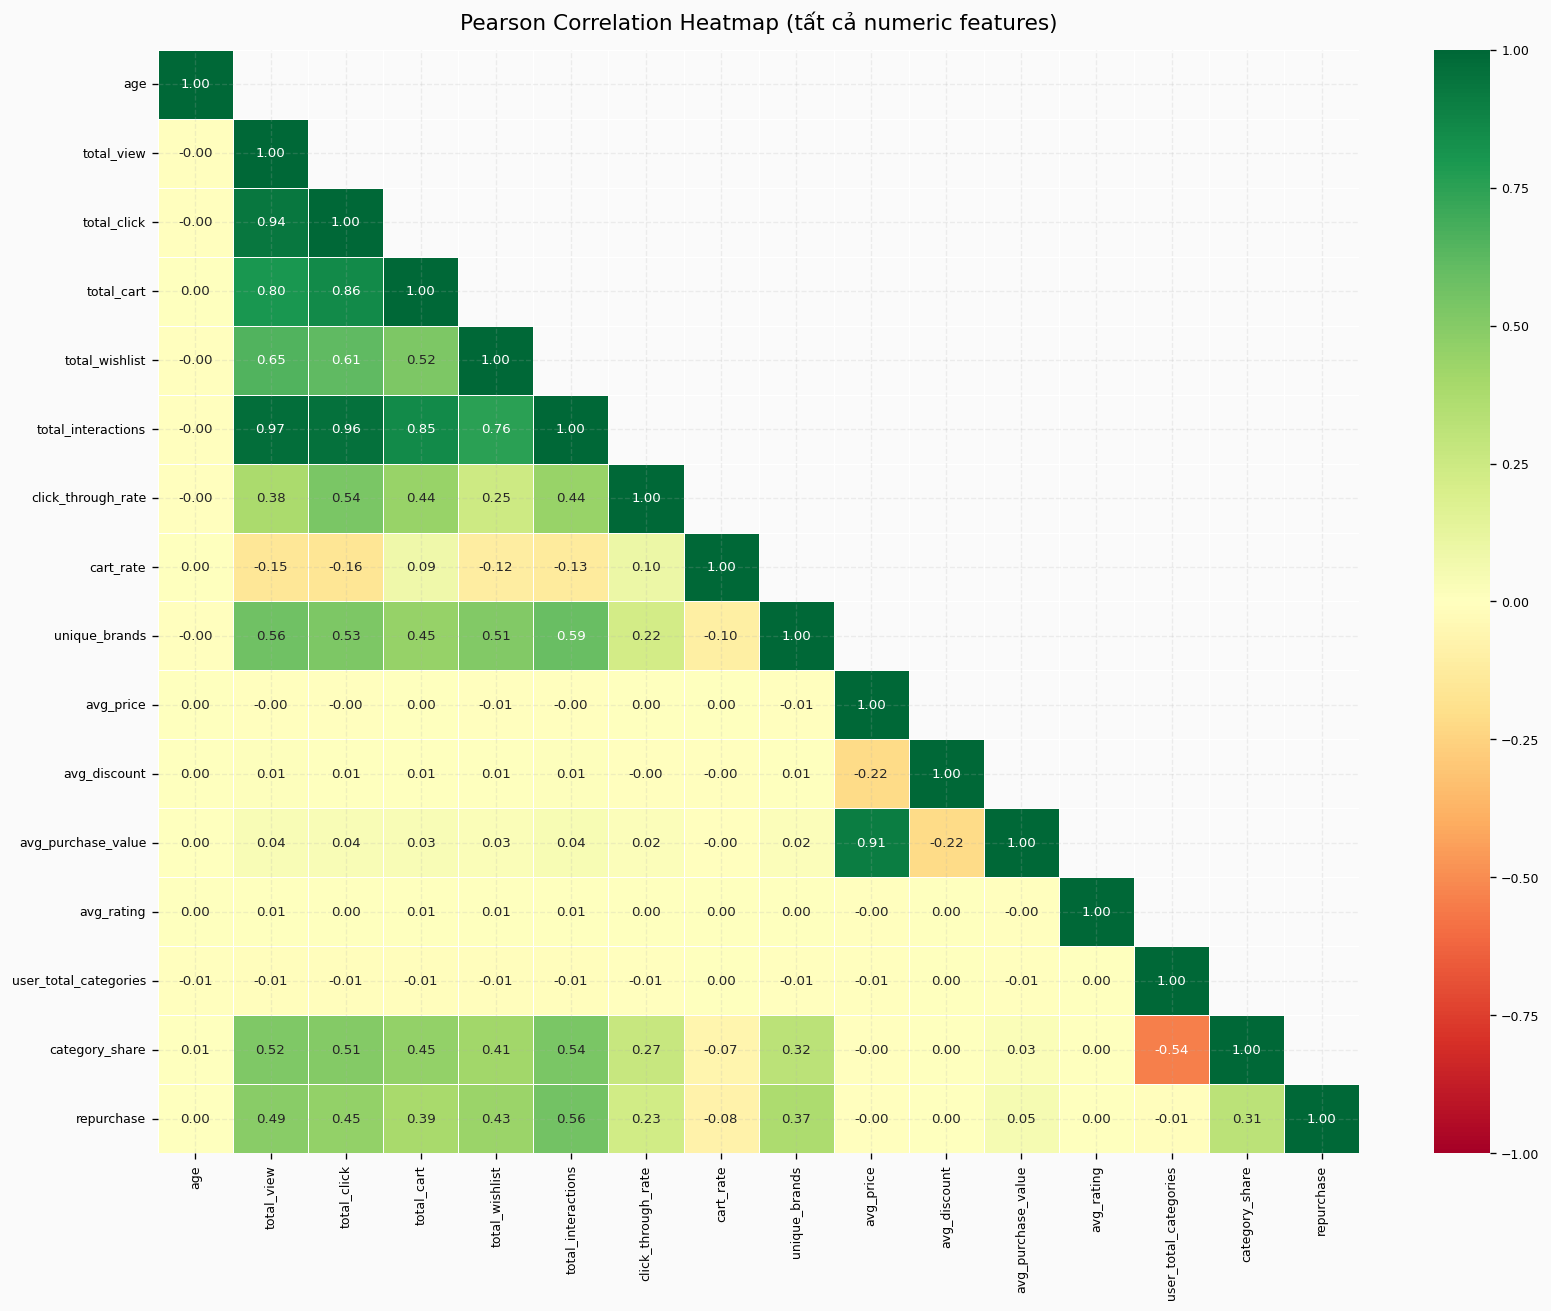


📋 TOP CORRELATION VỚI TARGET (repurchase):
total_interactions       0.5593
total_view               0.4866
total_click              0.4549
total_wishlist           0.4320
total_cart               0.3881
unique_brands            0.3725
category_share           0.3136
click_through_rate       0.2322
avg_purchase_value       0.0487
avg_discount             0.0022
age                      0.0012
avg_rating               0.0008
avg_price               -0.0003
user_total_categories   -0.0086
cart_rate               -0.0825


In [63]:
# ============================================================
# SECTION 4: Correlation heatmap
# ============================================================
df_corr = df[numeric_cols + ['repurchase']].copy()
df_corr['avg_rating'] = df_corr['avg_rating'].fillna(0)   # Impute trước khi tính correlation

corr_matrix = df_corr.corr(method='pearson')

# Mask tam giác trên
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 11))
heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Pearson Correlation Heatmap (tất cả numeric features)', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

# Top correlations với repurchase
repurchase_corr = corr_matrix['repurchase'].drop('repurchase').sort_values(ascending=False)
print('\n📋 TOP CORRELATION VỚI TARGET (repurchase):')
print(repurchase_corr.to_string())

## 5. Categorical Analysis + Chi-Square Test

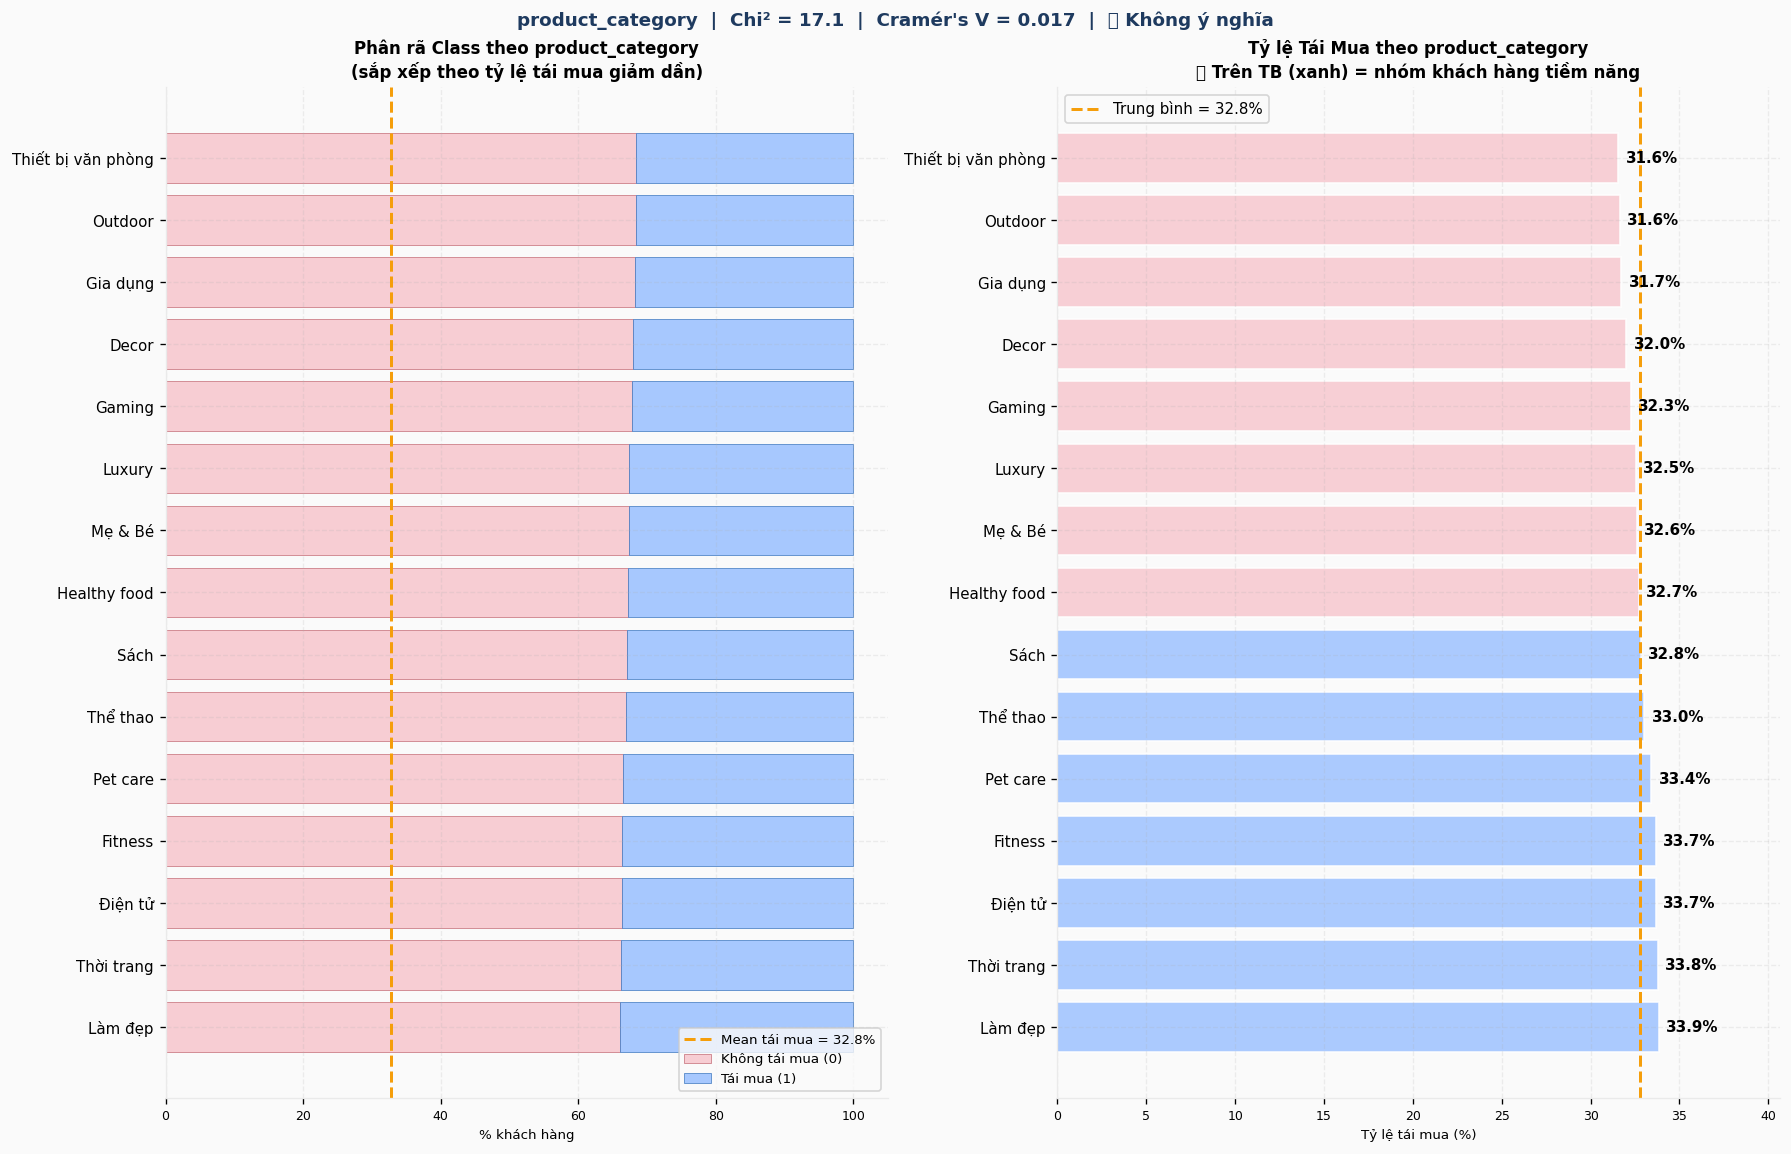


  product_category: Cramér's V = 0.0166  |  p = 2.53e-01


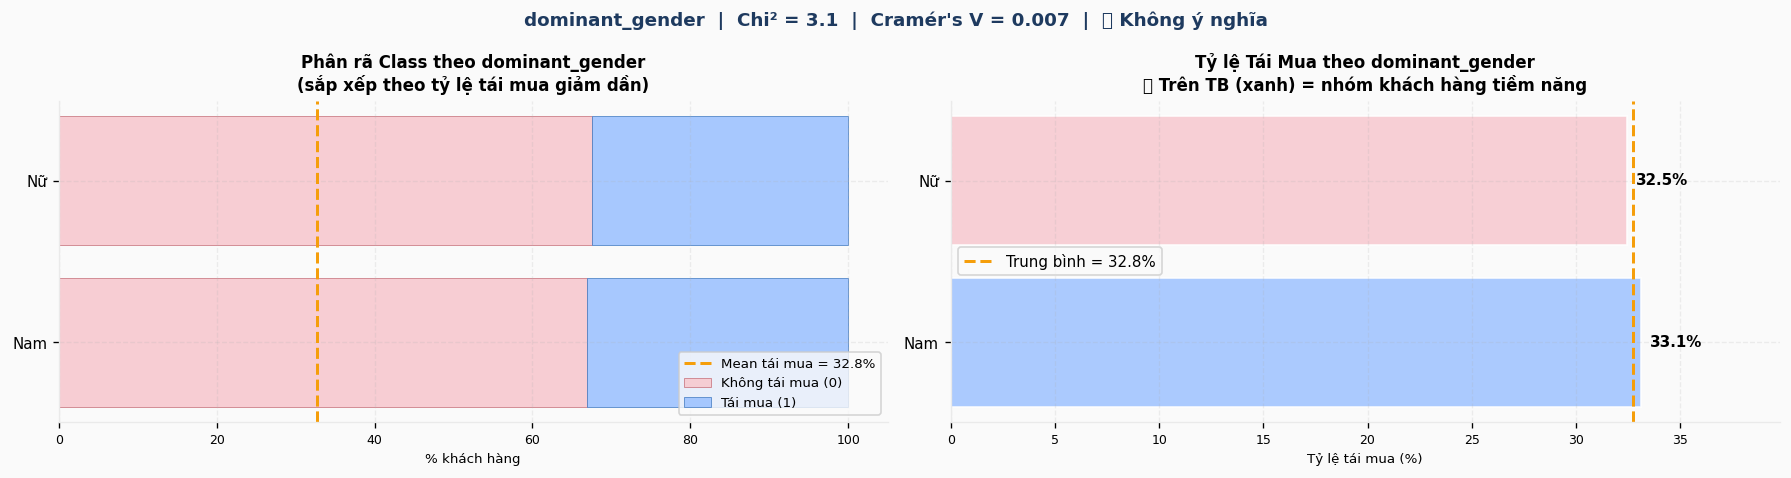


  dominant_gender: Cramér's V = 0.0071  |  p = 7.78e-02


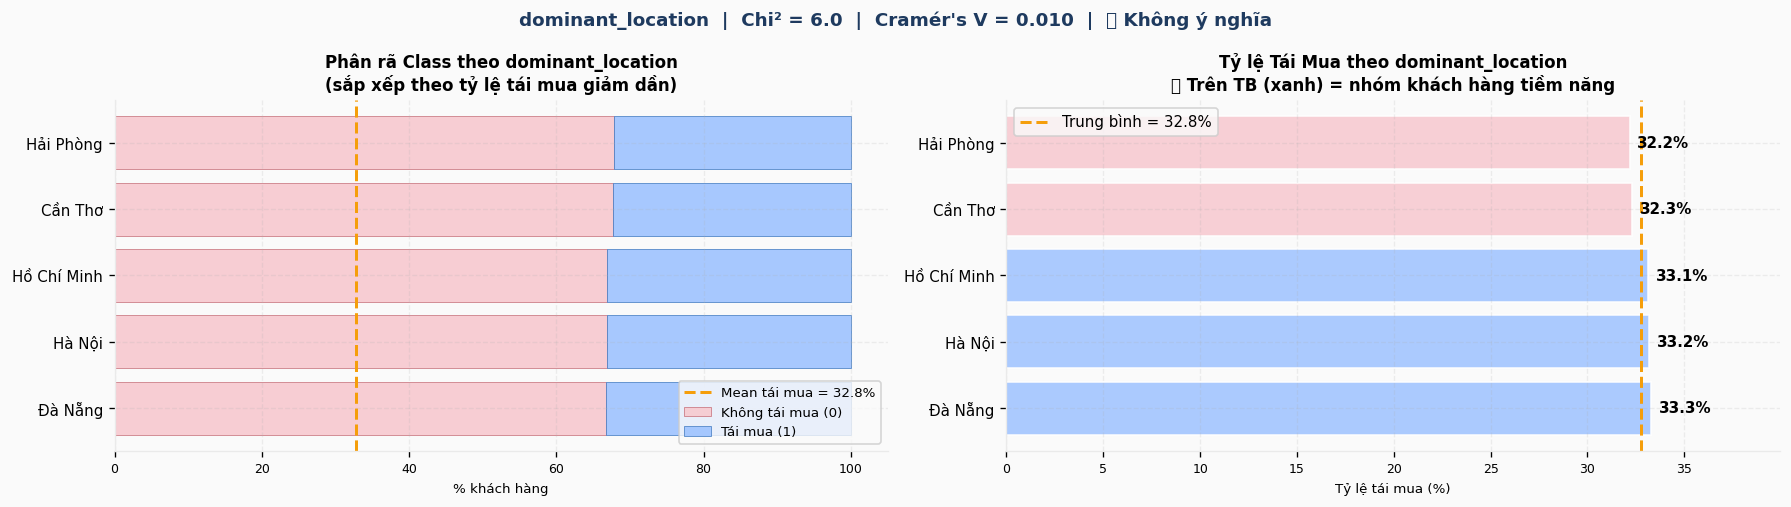


  dominant_location: Cramér's V = 0.0099  |  p = 1.98e-01


In [64]:
# ============================================================
# SECTION 5: Categorical features vs repurchase
# Màu: PALETTE[0]/PALETTE[1] cho phân rã class (hồng / xanh VI)
#      Bars "tỷ lệ tái mua": hồng/xanh theo giá trị vs mean
# ============================================================
cat_features = ['product_category', 'dominant_gender', 'dominant_location']

for col in cat_features:
    # Chi-square test
    contingency = pd.crosstab(df[col], df['repurchase'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    # Cramér's V
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    significance = '✅ Có ý nghĩa (p < 0.05)' if p_val < 0.05 else '❌ Không ý nghĩa'

    repurchase_rate = df.groupby(col)['repurchase'].mean().sort_values(ascending=False)
    overall_mean    = df['repurchase'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(repurchase_rate) * 0.55 + 1.5)))

    # ── Panel trái: Tỷ lệ class (stacked %) ────────────────────────────────
    cross_pct = pd.crosstab(df[col], df['repurchase'], normalize='index') * 100
    cross_pct.columns = ['Không tái mua (0)', 'Tái mua (1)']
    cross_pct = cross_pct.loc[repurchase_rate.index]

    y_pos = np.arange(len(cross_pct))
    axes[0].barh(y_pos, cross_pct['Không tái mua (0)'],
                 color=PALETTE[0], edgecolor=PALETTE_EDGE[0], linewidth=0.5, alpha=0.92, label='Không tái mua (0)')
    axes[0].barh(y_pos, cross_pct['Tái mua (1)'],
                 left=cross_pct['Không tái mua (0)'],
                 color=PALETTE[1], edgecolor=PALETTE_EDGE[1], linewidth=0.5, alpha=0.92, label='Tái mua (1)')
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(cross_pct.index, fontsize=9)
    axes[0].set_xlabel('% khách hàng')
    axes[0].set_title(f'Phân rã Class theo {col}\n(sắp xếp theo tỷ lệ tái mua giảm dần)',
                      fontsize=10, fontweight='bold')
    axes[0].axvline(overall_mean * 100, color=PAL['warning'], linewidth=1.8,
                    linestyle='--', label=f'Mean tái mua = {overall_mean*100:.1f}%')
    axes[0].legend(loc='lower right', fontsize=8)
    axes[0].set_facecolor('#FAFAFA')

    # ── Panel phải: Tỷ lệ tái mua — màu theo trên/dưới trung bình ─────────
    bar_colors = [PALETTE[1] if v > overall_mean else PALETTE[0]
                  for v in repurchase_rate.values]
    bars = axes[1].barh(np.arange(len(repurchase_rate)),
                        repurchase_rate.values * 100,
                        color=bar_colors, edgecolor='white', alpha=0.88)
    axes[1].set_yticks(np.arange(len(repurchase_rate)))
    axes[1].set_yticklabels(repurchase_rate.index, fontsize=9)
    axes[1].axvline(overall_mean * 100, color=PAL['warning'], linewidth=1.8,
                    linestyle='--', label=f'Trung bình = {overall_mean*100:.1f}%')
    # Annotate giá trị
    for bar, val in zip(bars, repurchase_rate.values * 100):
        axes[1].text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    axes[1].set_xlabel('Tỷ lệ tái mua (%)')
    axes[1].set_title(f'Tỷ lệ Tái Mua theo {col}\n🔵 Trên TB (xanh) = nhóm khách hàng tiềm năng',
                      fontsize=10, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].set_facecolor('#FAFAFA')
    axes[1].set_xlim(0, repurchase_rate.max() * 100 * 1.2)

    plt.suptitle(f'{col}  |  Chi² = {chi2:.1f}  |  Cramér\'s V = {cramers_v:.3f}  |  {significance}',
                 fontsize=11, fontweight='bold', color='#1E3A5F')
    plt.tight_layout()
    plt.show()

    print(f'\n  {col}: Cramér\'s V = {cramers_v:.4f}  |  p = {p_val:.2e}')


## 6. Outlier Detection

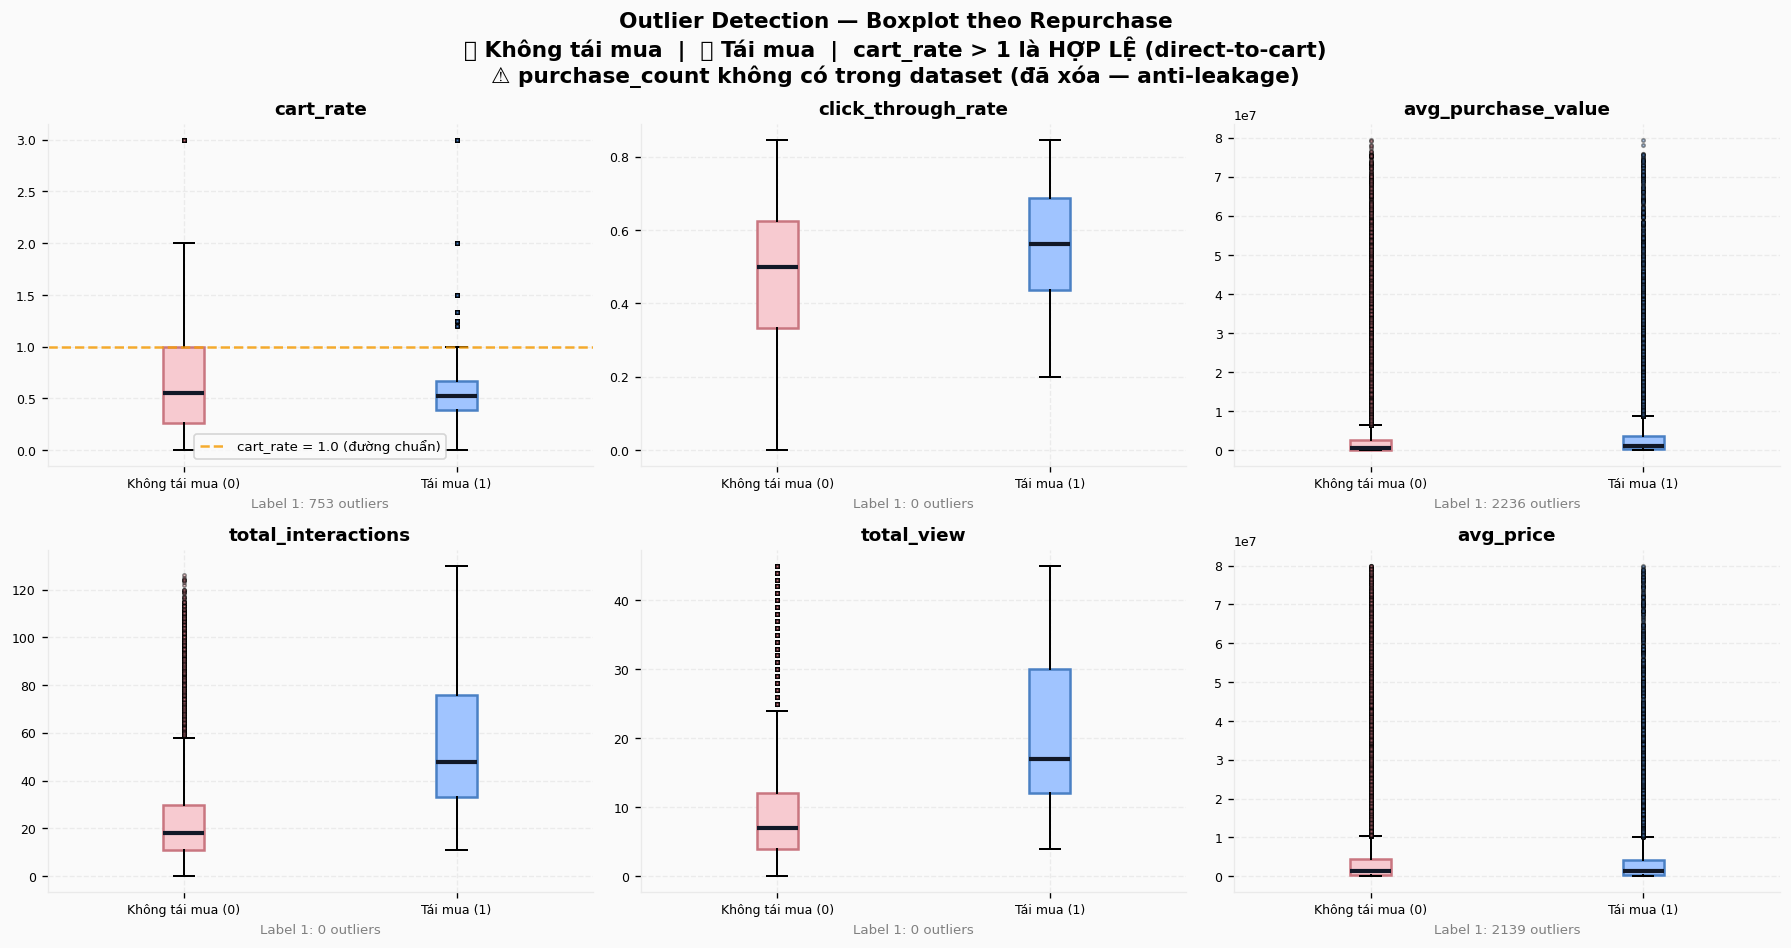


📋 IQR OUTLIER SUMMARY (toàn dataset):
  Biến                      Outliers   % tổng  Ghi chú
  ─────────────────────────────────────────────────────────────────
  cart_rate                    3,008    4.87%  ← direct-to-cart, KHÔNG clip
  click_through_rate               0    0.00%  
  avg_purchase_value           7,451   12.07%  ← avg 0 = chưa mua lần nào
  total_interactions           3,265    5.29%  
  total_view                   4,415    7.15%  
  avg_price                    6,392   10.36%  


In [65]:
# ============================================================
# SECTION 6: Outlier detection — Boxplot by repurchase
# Màu: PALETTE[0]/PALETTE[1] — VI class colors (hồng / xanh pastel)
# NOTE: purchase_count đã xóa → thay bằng total_interactions
# ============================================================
outlier_cols = ['cart_rate', 'click_through_rate', 'avg_purchase_value',
                'total_interactions', 'total_view', 'avg_price']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    data_0 = df[df['repurchase'] == 0][col].dropna()
    data_1 = df[df['repurchase'] == 1][col].dropna()

    bp = ax.boxplot(
        [data_0, data_1],
        labels=['Không tái mua (0)', 'Tái mua (1)'],
        patch_artist=True,
        boxprops=dict(facecolor='none', linewidth=1.5),
        medianprops=dict(color='#111827', linewidth=2.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.4)
    )
    # Tô màu theo Visual Identity (hồng / xanh)
    bp['boxes'][0].set_facecolor(PALETTE[0])
    bp['boxes'][0].set_edgecolor(PALETTE_EDGE[0])
    bp['fliers'][0].set_markerfacecolor(PALETTE_EDGE[0])
    bp['boxes'][1].set_facecolor(PALETTE[1])
    bp['boxes'][1].set_edgecolor(PALETTE_EDGE[1])
    bp['fliers'][1].set_markerfacecolor(PALETTE_EDGE[1])

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_facecolor('#FAFAFA')

    # IQR outlier count per class
    for data, label_str, color in [(data_0, '0', PALETTE_EDGE[0]), (data_1, '1', PALETTE_EDGE[1])]:
        q1, q3 = data.quantile(0.25), data.quantile(0.75)
        iqr = q3 - q1
        n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
        ax.set_xlabel(f'Label {label_str}: {n_out} outliers', fontsize=8, color='gray')

    # Chú thích cart_rate > 1 = hợp lệ
    if col == 'cart_rate':
        ax.axhline(1.0, color=PAL['warning'], linestyle='--', linewidth=1.5, alpha=0.85,
                   label='cart_rate = 1.0 (đường chuẩn)')
        ax.legend(fontsize=8)

plt.suptitle('Outlier Detection — Boxplot theo Repurchase\n'
             '🩷 Không tái mua  |  🔵 Tái mua  |  cart_rate > 1 là HỢP LỆ (direct-to-cart)\n'
             '⚠️ purchase_count không có trong dataset (đã xóa — anti-leakage)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# IQR outlier summary
print('\n📋 IQR OUTLIER SUMMARY (toàn dataset):')
print(f'  {"Biến":<25} {"Outliers":>8}  {"% tổng":>7}  Ghi chú')
print('  ' + '─' * 65)
for col in outlier_cols:
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    note = '← direct-to-cart, KHÔNG clip' if col == 'cart_rate' else \
           '← avg 0 = chưa mua lần nào' if col == 'avg_purchase_value' else ''
    print(f'  {col:<25} {n_out:>8,}  {n_out/len(df)*100:>6.2f}%  {note}')


## 7. Feature Correlation với Target

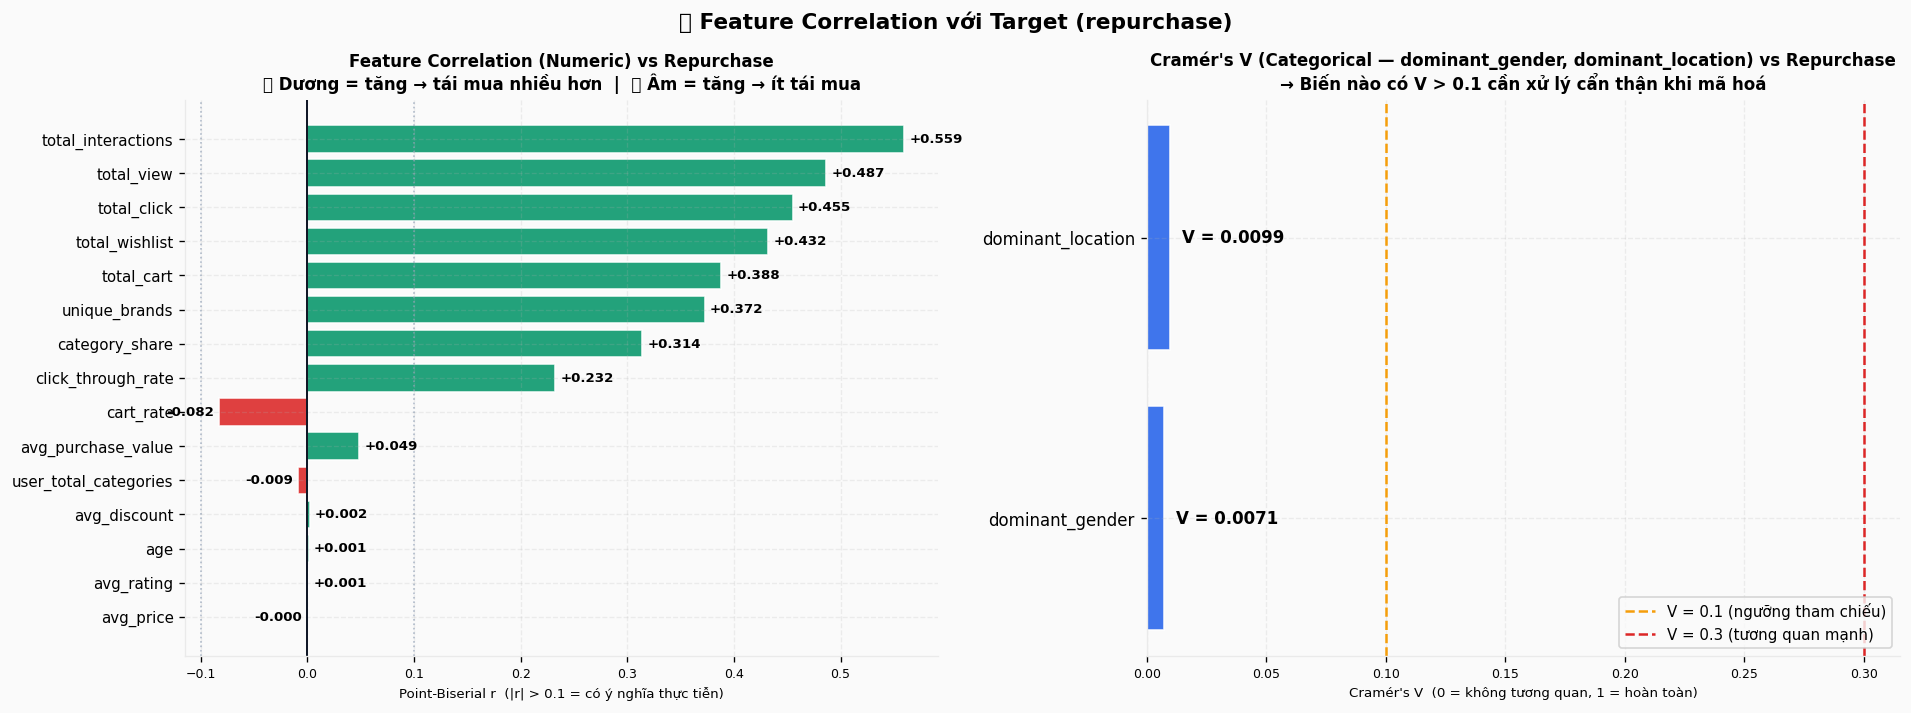


📋 POINT-BISERIAL CORRELATION (numeric):
                       Point-Biserial r p-value Significant
total_interactions               0.5593  0.0000           ✅
total_view                       0.4866  0.0000           ✅
total_click                      0.4549  0.0000           ✅
total_wishlist                   0.4320  0.0000           ✅
total_cart                       0.3881  0.0000           ✅
unique_brands                    0.3725  0.0000           ✅
category_share                   0.3136  0.0000           ✅
click_through_rate               0.2322  0.0000           ✅
cart_rate                       -0.0825  0.0000           ✅
avg_purchase_value               0.0487  0.0000           ✅
user_total_categories           -0.0086  0.0333           ✅
avg_discount                     0.0022  0.5886           ❌
age                              0.0012  0.7571           ❌
avg_rating                       0.0008  0.8504           ❌
avg_price                       -0.0003  0.9487           ❌

In [68]:
# ============================================================
# SECTION 7: Point-Biserial + Cramér's V (Feature Correlation vs Target)
# Màu: PAL['pos'] = tương quan dương, PAL['neg'] = tương quan âm
#      PAL['primary'] = Cramér's V (metric đơn, không có chiều)
# ============================================================
from scipy.stats import pointbiserialr

df_analysis = df.copy()
df_analysis['avg_rating'] = df_analysis['avg_rating'].fillna(0)

# --- Point-Biserial cho numeric ---
pb_results = {}
for col in numeric_cols:
    valid = df_analysis[[col, 'repurchase']].dropna()
    corr, pval = pointbiserialr(valid[col], valid['repurchase'])
    pb_results[col] = {'Point-Biserial r': corr, 'p-value': pval,
                       'Significant': '✅' if pval < 0.05 else '❌'}

pb_df = pd.DataFrame(pb_results).T.sort_values('Point-Biserial r', key=abs, ascending=False)
pb_df['Point-Biserial r'] = pb_df['Point-Biserial r'].astype(float)

# --- Cramér's V cho categorical ---
# ⚠️  product_category là KEY column (composite key với user_id) → KHÔNG phân tích như feature
cramers_results = {}
for col in ['dominant_gender', 'dominant_location']:
    contingency = pd.crosstab(df[col], df['repurchase'])
    chi2, pval, _, _ = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    cramers_results[col] = {"Cramér's V": cramers_v, 'p-value': pval,
                            'Significant': '✅' if pval < 0.05 else '❌'}

cramers_df = pd.DataFrame(cramers_results).T.sort_values("Cramér's V", ascending=False)

# --- Visualize (2 panel side-by-side) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel trái: Point-Biserial r ─────────────────────────────────────────────
pb_vals = pb_df['Point-Biserial r'].astype(float)
# Màu: xanh = tương quan dương (tái mua ↑), đỏ = âm (tái mua ↓)
pb_colors = [PAL['pos'] if v > 0 else PAL['neg'] for v in pb_vals.values]
bars = axes[0].barh(range(len(pb_vals)), pb_vals.values[::-1],
                    color=pb_colors[::-1], edgecolor='white', alpha=0.88)
axes[0].set_yticks(range(len(pb_vals)))
axes[0].set_yticklabels(pb_vals.index[::-1], fontsize=9)
axes[0].axvline(0, color='#111827', linewidth=1.2)
axes[0].axvline( 0.1, color=PAL['neutral'], linewidth=1, linestyle=':', alpha=0.7)
axes[0].axvline(-0.1, color=PAL['neutral'], linewidth=1, linestyle=':', alpha=0.7)
# Annotate giá trị
for bar, val in zip(bars, pb_vals.values[::-1]):
    sign = '+' if val > 0 else ''
    axes[0].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height()/2,
                 f'{sign}{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
                 fontsize=8, fontweight='bold')
axes[0].set_xlabel('Point-Biserial r  (|r| > 0.1 = có ý nghĩa thực tiễn)')
axes[0].set_title('Feature Correlation (Numeric) vs Repurchase\n'
                  '🟢 Dương = tăng → tái mua nhiều hơn  |  🔴 Âm = tăng → ít tái mua',
                  fontsize=10, fontweight='bold')
axes[0].set_facecolor('#FAFAFA')

# ── Panel phải: Cramér's V ────────────────────────────────────────────────────
cramers_vals = cramers_df["Cramér's V"].astype(float)
# Dùng PAL['primary'] (xanh dương đậm) — metric đơn, không có chiều dương/âm
cr_colors = [PAL['primary']] * len(cramers_vals)
bars2 = axes[1].barh(range(len(cramers_vals)), cramers_vals.values[::-1],
                     color=cr_colors, edgecolor='white', alpha=0.88)
axes[1].set_yticks(range(len(cramers_vals)))
axes[1].set_yticklabels(cramers_vals.index[::-1], fontsize=10)
axes[1].axvline(0.1, color=PAL['warning'], linewidth=1.5, linestyle='--',
                label='V = 0.1 (ngưỡng tham chiếu)')
axes[1].axvline(0.3, color=PAL['neg'],     linewidth=1.5, linestyle='--',
                label='V = 0.3 (tương quan mạnh)')
for bar, val in zip(bars2, cramers_vals.values[::-1]):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'V = {val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel("Cramér's V  (0 = không tương quan, 1 = hoàn toàn)")
axes[1].set_title("Cramér's V (Categorical — dominant_gender, dominant_location) vs Repurchase\n"
                  "→ Biến nào có V > 0.1 cần xử lý cẩn thận khi mã hoá",
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_facecolor('#FAFAFA')

plt.suptitle('🔗 Feature Correlation với Target (repurchase)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 POINT-BISERIAL CORRELATION (numeric):')
print(pb_df[['Point-Biserial r', 'p-value', 'Significant']].to_string())
print(f'\n📋 CRAMÉR\'S V (categorical — dominant_gender, dominant_location):')
print('   ⚠️  product_category là KEY column (composite key với user_id) → không phân tích ở đây')
print(cramers_df.to_string())


## 8. Kết luận EDA

In [67]:
# ============================================================
# SECTION 8: EDA Summary
# ============================================================
print('=' * 65)
print('  📋 KẾT LUẬN EDA')
print('=' * 65)

counts = df['repurchase'].value_counts()
imbalance = counts.min() / counts.max()
print(f'\n  1️⃣  CLASS IMBALANCE')
print(f'      Tái mua (1)       : {counts.get(1, 0):,}  ({counts.get(1, 0)/len(df)*100:.1f}%)')
print(f'      Không tái mua (0) : {counts.get(0, 0):,}  ({counts.get(0, 0)/len(df)*100:.1f}%)')
print(f'      Ratio (minority/majority) = {imbalance:.3f}')
print(f'      → Mất cân bằng vừa, dùng class_weight="balanced" hoặc SMOTE')
print(f'      → Primary metric: F1-Score thay vì Accuracy')
print(f'      → Nhãn được tạo bởi Otsu Thresholding trên purchase_count (T*=4.02)')

print(f'\n  2️⃣  MISSING VALUES')
print(f'      avg_rating: ~28% NaN')
print(f'      → Strategy NB3: Impute NaN = median (4.0)')
print(f'      → Có thể tạo thêm feature has_rating (binary)')

print(f'\n  3️⃣  TOP FEATURES DỰ KIẾN (theo correlation với target)')
top5 = pb_df['Point-Biserial r'].astype(float).abs().sort_values(ascending=False).head(5)
for rank, (col, val) in enumerate(top5.items(), 1):
    print(f'      {rank}. {col:<30} |r| = {val:.4f}')

print(f'\n  4️⃣  OUTLIERS')
print(f'      cart_rate > 1: HỢP LỆ (direct-to-cart behavior)')
print(f'      avg_purchase_value = 0: HỢP LỆ (chưa mua lần nào)')
print(f'      purchase_count: đã xóa khỏi dataset (anti-leakage)')
print(f'      → Không clip outliers, để model tự học pattern')

print(f'\n  5️⃣  CATEGORICAL FEATURES')
print(f'      product_category: Cramér\'s V cao nhất → quan trọng')
print(f'      → Drop user_id, product_category khỏi X (identifiers)')
print(f'      → Label Encode: dominant_gender, dominant_location')

print(f'\n  → Notebook 3: Preprocessing + Feature Engineering + Train 3 models (LR / RF / LightGBM)')
print('=' * 65)


  📋 KẾT LUẬN EDA

  1️⃣  CLASS IMBALANCE
      Tái mua (1)       : 20,221  (32.8%)
      Không tái mua (0) : 41,507  (67.2%)
      Ratio (minority/majority) = 0.487
      → Mất cân bằng vừa, dùng class_weight="balanced" hoặc SMOTE
      → Primary metric: F1-Score thay vì Accuracy
      → Nhãn được tạo bởi Otsu Thresholding trên purchase_count (T*=4.02)

  2️⃣  MISSING VALUES
      avg_rating: ~28% NaN
      → Strategy NB3: Impute NaN = median (4.0)
      → Có thể tạo thêm feature has_rating (binary)

  3️⃣  TOP FEATURES DỰ KIẾN (theo correlation với target)
      1. total_interactions             |r| = 0.5593
      2. total_view                     |r| = 0.4866
      3. total_click                    |r| = 0.4549
      4. total_wishlist                 |r| = 0.4320
      5. total_cart                     |r| = 0.3881

  4️⃣  OUTLIERS
      cart_rate > 1: HỢP LỆ (direct-to-cart behavior)
      avg_purchase_value = 0: HỢP LỆ (chưa mua lần nào)
      purchase_count: đã xóa khỏi dataset (a